# Priority-Constrained Descent: a hands-on tour

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DaraVaram/priority-constrained-descent/blob/main/notebooks/pcd_tutorial.ipynb)

Many training problems have one objective that is the point, such as task accuracy, and others that only constrain it, such as sparsity or low rank. **Priority-Constrained Descent (PCD)** treats them that way: every step follows the primary objective's gradient as closely as it can, while giving each secondary objective a guaranteed share of progress. One tolerance, τ, sets that share, in place of loss weights.

This notebook runs on a CPU in a few minutes. It covers:

1. a two-dimensional problem where a weighted sum stalls and PCD does not,
2. what PCD does inside a single step,
3. feature selection with τ as the only knob,
4. why τ does not need retuning when a loss is rescaled,
5. three objectives with a different τ for each,
6. how to use PCD in your own training loop.

Paper: Dara Varam and Mohamed I. AlHajri, *Not All Objectives Are Born Equal: Priority-Constrained Descent for Hierarchical Multi-Objective Optimization*, TMLR 2026 ([OpenReview](https://openreview.net/forum?id=HT01yGHLEt) · [arXiv](https://arxiv.org/abs/2606.29521) · [code](https://github.com/DaraVaram/priority-constrained-descent) · [project page](https://daravaram.github.io/PCD/)).

## Setup

In [1]:
import importlib.util

if importlib.util.find_spec("pcd") is None:  # e.g. on Colab
    %pip install -q git+https://github.com/DaraVaram/priority-constrained-descent

In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from pcd import PCD

PURPLE, ORANGE, GREY = "#6A1B9A", "#EF6C00", "#9aa0b4"

## The idea in one equation

With gradients $g_1$ (the primary) and $g_2, \dots, g_K$ (the secondaries), PCD's direction is

$$
\tilde d^\star = \arg\min_{d}\ \tfrac12\lVert d-\tilde g_1\rVert^2
\quad\text{s.t.}\quad \tilde g_j^\top d \ \ge\ \tau\,\lVert\tilde g_j\rVert^2 \quad \text{for every secondary } j .
$$

The update stays as close as possible to the primary gradient, subject to each secondary receiving at least a fraction τ of the first-order progress a step along its own gradient would make. The $\tilde g_i$ are the gradients divided by a running estimate of their size, so τ means the same thing for every objective whatever its scale. The direction is then rescaled to the length of $g_1$, so any optimizer and learning-rate schedule can take the step.

In code, `pcd.backward([primary, *secondaries])` replaces `loss.backward()`:

```python
pcd = PCD(model.parameters(), tau=0.02)
...
info = pcd.backward([task_loss, penalty])   # writes the PCD direction into .grad
optimizer.step()
```

## 1. When a weighted sum stalls

This is the toy problem of the paper's Fig. 1. The primary $L_1$ is a double well with minima at $(-2, 0)$ and $(2, 0)$. The secondary $L_2$ is the $\ell_1$ distance to a small box around $(2, 0)$ (shaded), so only the right-hand minimum is good for both. Every run starts in the left basin and uses Adam.

In [3]:
STAR = torch.tensor([2.0, 0.0], dtype=torch.float64)
INITS = [(-2.55, 0.40), (-2.90, 0.12), (-1.65, -0.55)]


def primary(theta):
    return (theta[..., 0] ** 2 - 4) ** 2 / 4 + theta[..., 1] ** 2 / 2


def secondary(theta):
    return torch.relu((theta - STAR).abs() - 0.5).sum(-1)


def run(method, init, steps=3000, lr=0.01, tau=0.3):
    theta = torch.nn.Parameter(torch.tensor(init, dtype=torch.float64))
    opt = torch.optim.Adam([theta], lr=lr)
    pcd = PCD([theta], tau=tau)
    path, infos = [theta.detach().clone()], []
    for _ in range(steps):
        opt.zero_grad()
        if method == "PCD":
            infos.append(pcd.backward([primary(theta), secondary(theta)]))
        else:
            (0.5 * primary(theta) + 0.5 * secondary(theta)).backward()
        opt.step()
        path.append(theta.detach().clone())
    return torch.stack(path), infos


runs = {(m, i): run(m, init) for m in ("Weighted sum", "PCD") for i, init in enumerate(INITS)}
for (m, i), (path, _) in runs.items():
    end = path[-1]
    print(f"{m:>12} from {INITS[i]} -> ({end[0]:+.3f}, {end[1]:+.3f})   "
          f"L1 = {primary(end):.4f}   L2 = {secondary(end):.4f}")

Weighted sum from (-2.55, 0.4) -> (-1.861, +0.000)   L1 = 0.0722   L2 = 3.3608
Weighted sum from (-2.9, 0.12) -> (-1.861, -0.000)   L1 = 0.0722   L2 = 3.3608
Weighted sum from (-1.65, -0.55) -> (-1.861, -0.000)   L1 = 0.0722   L2 = 3.3608
         PCD from (-2.55, 0.4) -> (+2.000, -0.000)   L1 = 0.0000   L2 = 0.0000
         PCD from (-2.9, 0.12) -> (+2.000, +0.000)   L1 = 0.0000   L2 = 0.0000
         PCD from (-1.65, -0.55) -> (+2.000, -0.000)   L1 = 0.0000   L2 = 0.0000


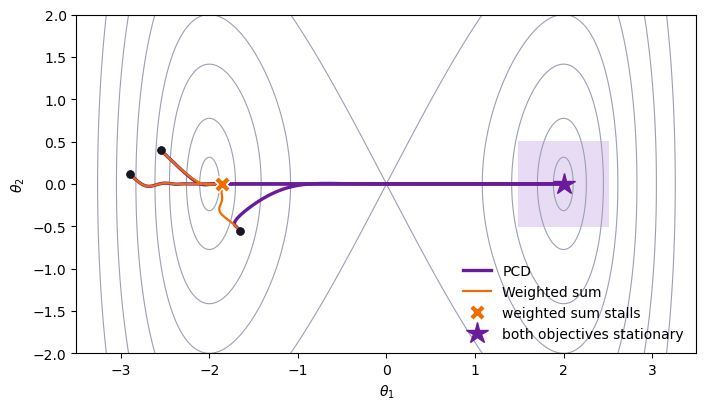

In [4]:
xs, ys = torch.meshgrid(torch.linspace(-3.5, 3.5, 400), torch.linspace(-2, 2, 240), indexing="xy")
grid = torch.stack([xs, ys], -1).double()
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.contour(xs, ys, primary(grid), levels=[0.05, 0.3, 1, 2, 4, 7, 11], colors=GREY, linewidths=0.8)
ax.contourf(xs, ys, secondary(grid) == 0, levels=[0.5, 1.5], colors=["#e8dcf4"])
for (m, i), (path, _) in sorted(runs.items(), key=lambda kv: kv[0][0] != "PCD"):
    is_pcd = m == "PCD"
    ax.plot(path[:, 0], path[:, 1], color=PURPLE if is_pcd else ORANGE, lw=2.4 if is_pcd else 1.6,
            label=None if i else m)
    ax.plot(*path[0], "o", color="#1a1523", ms=5)
    if not is_pcd:
        ax.plot(*path[-1], "X", color=ORANGE, ms=11, mec="white",
                label=None if i else "weighted sum stalls")
ax.plot(*STAR, "*", color=PURPLE, ms=16, label="both objectives stationary")
ax.set(xlabel=r"$\theta_1$", ylabel=r"$\theta_2$")
ax.legend(loc="lower right", frameon=False)
plt.show()

The weighted sum stops where the two gradients cancel. That point is not a minimum of $L_1$: it is where $L_2$'s pull toward the box is exactly cancelled by $L_1$'s pull back into the left well. PCD never lets the secondary's progress drop below its τ-share, so it crosses the barrier and stops at $(2, 0)$, where both objectives are stationary.

## 2. Inside a step

`pcd.backward` returns a `PCDInfo` with the step's diagnostics: the cosine between the primary and each secondary gradient, the multiplier `mu` of each constraint (the weight the secondary's normalized gradient gets in the direction) and which constraints were `active`. Here is one PCD run from above, step by step.

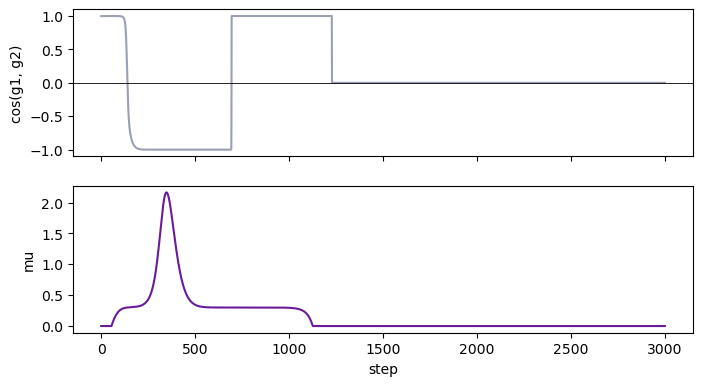

constraint active on 1071 of 3000 steps


In [5]:
path, infos = runs["PCD", 0]
cos = [info.cosine[0] for info in infos]
mu = [info.mu[0] for info in infos]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4.2), sharex=True)
ax1.plot(cos, color=GREY)
ax1.axhline(0, color="black", lw=0.6)
ax1.set_ylabel("cos(g1, g2)")
ax2.plot(mu, color=PURPLE)
ax2.set(ylabel="mu", xlabel="step")
plt.show()

active = sum(bool(info.active) for info in infos)
print(f"constraint active on {active} of {len(infos)} steps")

The constraint binds whenever the primary gradient on its own would give the secondary less than its τ-share of progress; the secondary's gradient is then mixed in just enough to make up the difference. That is always the case while the two conflict (cosine −1, climbing out of the left well), and there `mu` peaks. It also happens when they agree but the primary gradient is small compared with its usual size, near the bottom of a well: that is the plateau at `mu` ≈ τ = 0.3. Once the primary gradient provides the share by itself, or the secondary is satisfied (inside the box its gradient is zero and the cosine reads 0), `mu` is zero and PCD steps along the primary gradient unchanged.

## 3. Feature selection: τ is the only knob

Now a small network. Only 5 of 40 input features carry signal. The primary objective is the cross-entropy; the secondary is a group lasso over the first layer's input columns, which pushes whole features out of the network. We sweep τ and count the features that survive. Each run takes a few seconds.

In [6]:
FEATURES, INFORMATIVE = 40, 5


def make_data(n, seed):
    gen = torch.Generator().manual_seed(seed)
    x = torch.randn(n, FEATURES, generator=gen)
    w = torch.randn(INFORMATIVE, generator=torch.Generator().manual_seed(123))
    z = x[:, :INFORMATIVE] @ w + 0.8 * torch.sin(2 * x[:, 0]) * x[:, 1]
    return x, (z > 0).long()


x_train, y_train = make_data(4000, seed=1)
x_test, y_test = make_data(2000, seed=2)


def features_penalty(model):
    return model[0].weight.norm(dim=0).sum()        # one group per input feature


def train(update, epochs=60, batch_size=128, lr=3e-3):
    """Train a small MLP; ``update(model, task_loss)`` must fill in the gradients."""
    torch.manual_seed(0)
    model = nn.Sequential(nn.Linear(FEATURES, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    for _ in range(epochs):
        for idx in torch.randperm(len(x_train)).split(batch_size):
            opt.zero_grad()
            update(model, F.cross_entropy(model(x_train[idx]), y_train[idx]))
            opt.step()
        sched.step()
    return model


def evaluate(model):
    with torch.no_grad():
        acc = (model(x_test).argmax(1) == y_test).float().mean().item()
        kept = model[0].weight.norm(dim=0) > 1e-2
    return 100 * acc, int(kept.sum()), int(kept[:INFORMATIVE].sum())


def pcd_update(tau, scale=1.0):
    pcd = None

    def update(model, task):
        nonlocal pcd
        if pcd is None:
            pcd = PCD(model.parameters(), tau=tau)
        pcd.backward([task, scale * features_penalty(model)])
    return update


taus = [0.0, 0.05, 0.1, 0.2, 0.5]
results = [evaluate(train(pcd_update(tau))) for tau in taus]
print(" tau   test acc   features kept   informative kept")
for tau, (acc, kept, informative) in zip(taus, results):
    print(f"{tau:4.2f}   {acc:6.1f}%   {kept:6d} / {FEATURES}   {informative:8d} / {INFORMATIVE}")

 tau   test acc   features kept   informative kept
0.00     84.6%       40 / 40          5 / 5
0.05     95.0%       40 / 40          5 / 5
0.10     97.9%       12 / 40          5 / 5
0.20     98.3%        5 / 40          5 / 5
0.50     95.7%        5 / 40          5 / 5


At τ = 0 the penalty is only kept from getting worse to first order, and all 40 features stay. As τ grows the penalty gets a larger share of every step: around τ = 0.2, PCD keeps exactly the 5 informative features, and test accuracy is highest. Pushing τ further trades accuracy for the penalty. Sweeping τ traces the whole trade-off.

## 4. τ does not care how you scale your losses

A weighted sum's λ is tied to the scale of the penalty: count the groups differently, change the layer width or measure in other units, and the same λ means something else. PCD divides each gradient by a running estimate of its own size, so multiplying a loss by a constant leaves the update unchanged. Below, the penalty is multiplied by 0.1, 1 and 10.

In [7]:
print("PCD, tau = 0.2")
for scale in (0.1, 1.0, 10.0):
    acc, kept, informative = evaluate(train(pcd_update(0.2, scale)))
    print(f"  penalty x {scale:<4}  acc {acc:5.1f}%   features kept {kept:2d}   informative kept {informative}")


def weighted_sum_update(lam, scale=1.0):
    def update(model, task):
        (task + lam * scale * features_penalty(model)).backward()
    return update


print("Weighted sum")
for lam in (0.003, 0.01, 0.03):
    for scale in (1.0, 10.0):
        acc, kept, informative = evaluate(train(weighted_sum_update(lam, scale)))
        print(f"  lambda {lam:<5} penalty x {scale:<4}  acc {acc:5.1f}%   "
              f"features kept {kept:2d}   informative kept {informative}")

PCD, tau = 0.2


  penalty x 0.1   acc  98.3%   features kept  5   informative kept 5


  penalty x 1.0   acc  98.3%   features kept  5   informative kept 5


  penalty x 10.0  acc  98.3%   features kept  5   informative kept 5
Weighted sum


  lambda 0.003 penalty x 1.0   acc  87.5%   features kept 40   informative kept 5


  lambda 0.003 penalty x 10.0  acc  97.4%   features kept 13   informative kept 5


  lambda 0.01  penalty x 1.0   acc  96.2%   features kept 40   informative kept 5


  lambda 0.01  penalty x 10.0  acc  89.3%   features kept  5   informative kept 5


  lambda 0.03  penalty x 1.0   acc  97.4%   features kept 13   informative kept 5


  lambda 0.03  penalty x 10.0  acc  89.6%   features kept  3   informative kept 3


PCD gives the same model at every scale. The weighted sum's outcome moves with the scale: λ = 0.03 selects 13 features with the original penalty and cuts into the informative ones once the penalty is ten times larger. A well-tuned λ can do well, but it has to be tuned again whenever the loss's scale changes. The paper shows the same effect on CIFAR networks.

## 5. More than two objectives

Add a third objective: the nuclear norm of the second layer's weight matrix, which pushes it toward low rank. The secondaries are constraints and are treated alike, so their order does not matter, and each can have its own τ. Here the feature penalty keeps τ = 0.2 and the rank penalty gets 0, 0.01 or 0.05.

In [8]:
def three_objective_update(taus):
    pcd = None

    def update(model, task):
        nonlocal pcd
        if pcd is None:
            pcd = PCD(model.parameters(), tau=taus)
        nuclear = torch.linalg.matrix_norm(model[2].weight, ord="nuc")
        pcd.backward([task, features_penalty(model), nuclear])
    return update


for rank_tau in (0.0, 0.01, 0.05):
    model = train(three_objective_update([0.2, rank_tau]))
    acc, kept, informative = evaluate(model)
    rank = int((torch.linalg.svdvals(model[2].weight.detach()) > 1e-2).sum())
    print(f"tau = [0.2, {rank_tau:<4}]  acc {acc:5.1f}%   features kept {kept:2d}   rank of layer 2: {rank:2d} / 64")

tau = [0.2, 0.0 ]  acc  98.3%   features kept  5   rank of layer 2: 33 / 64


tau = [0.2, 0.01]  acc  98.1%   features kept  5   rank of layer 2:  6 / 64


tau = [0.2, 0.05]  acc  96.7%   features kept  5   rank of layer 2:  2 / 64


The first row matches section 3: τ = 0 only keeps the rank penalty from growing. Giving it a small share compresses the second layer to a handful of directions at a modest cost in accuracy.

With three or more objectives the constraints can occasionally be mutually incompatible, for example two secondaries with exactly opposite gradients. PCD then follows the primary for that step and reports `info.feasible == False`. In high dimensions this essentially never happens.

## 6. In your own training loop

```python
from pcd import PCD

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)    # any optimizer
pcd = PCD(model.parameters(), tau=0.02)                         # or tau=[...] per secondary

for batch in loader:
    task = task_loss(model, batch)                  # the objective you care about, first
    info = pcd.backward([task, penalty_1(model), penalty_2(model)])
    optimizer.step()
```

- **Put the objective you care about first.** The others are constraints.
- **Choosing τ.** In the paper's CIFAR pruning experiments the useful range is τ ≤ 0.1, with τ = 0.02 as the representative setting. Sweep τ to trace the trade-off.
- **Nonsmooth secondaries are fine.** ℓ1, group lasso, nuclear norm and hinge penalties all work with the subgradients autograd returns.
- **Cost.** One backward pass per objective, like any method that manipulates per-objective gradients, plus a K×K solve.
- **Checkpointing.** Save `pcd.state_dict()` alongside the optimizer; it holds the normalization state.
- **Data-parallel training and gradient accumulation.** Compute or all-reduce each loss's gradients yourself and pass them to `pcd.apply_gradients(grads)`. The [README](https://github.com/DaraVaram/priority-constrained-descent#applying-pcd-to-your-own-problem) has the details, and a NumPy version for other frameworks.

## Citation

```bibtex
@article{varam2026pcd,
  title         = {Not All Objectives Are Born Equal: Priority-Constrained
                   Descent for Hierarchical Multi-Objective Optimization},
  author        = {Varam, Dara and AlHajri, Mohamed I.},
  journal       = {Transactions on Machine Learning Research},
  issn          = {2835-8856},
  year          = {2026},
  url           = {https://openreview.net/forum?id=HT01yGHLEt},
  eprint        = {2606.29521},
  archivePrefix = {arXiv},
  primaryClass  = {cs.LG}
}
```